In [1]:
import json
import os

from collections import Counter
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import nltk
from nltk import word_tokenize

from textblob import TextBlob
from transformers import pipeline

In [2]:
IMAGE_OUTPUT_FOLDER = 'outputFiles'

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/isabel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
try:
    with open('../dataProcessed/nurseNotesProcessed.json', 'r') as file:
        nurse_notes = json.load(file)
    print("File loaded successfully.")
    
except FileNotFoundError:
    print("Error: The file 'data.json' was not found.")

File loaded successfully.


In [5]:
# If picture folder does not exist, make it.
if not os.path.exists(f'./{IMAGE_OUTPUT_FOLDER}/'):
    os.makedirs(f'./{IMAGE_OUTPUT_FOLDER}/', exist_ok=False)  

In [6]:
def make_metric_df(key):    
    # Make DataFrame
    patient = nurse_notes[key]
    patient_df = pd.DataFrame(patient)

    # Format times.
    patient_df['Date'] = pd.to_datetime(patient_df['Date'], format="%Y-%m-%d", errors="coerce")
    patient_df.loc[patient_df["Date"].dt.year == 2026, "Date"] = patient_df.loc[patient_df["Date"].dt.year == 2026, "Date"].apply(lambda d: d.replace(year=2025))
    patient_df['Time'] = pd.to_datetime(patient_df['Time'], format="%H:%M:%S", errors="coerce").dt.time
    patient_df = patient_df.sort_values(by=["Date", "Time"])
    patient_df["DateTime"] = patient_df.apply(
        lambda row: pd.Timestamp.combine(row["Date"], row["Time"]),
        axis=1
    )

    character_counts = []
    word_counts = []
    textblob_sentiments = []
    textblob_subjectivites = []

    # prepare transformer for sentiment analysis - default pipeline model as of Feb 2025 used https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english
    classifier = pipeline("sentiment-analysis", model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')
    results = classifier(list(patient_df['Note']))
    transformer_sentiment = []
    for note, res in zip(patient_df['Note'], results):
        if res['label'] == 'NEGATIVE':
            transformer_sentiment.append(res['score'] * -1)
        elif res['label'] == 'POSITIVE':
            transformer_sentiment.append(res['score'])
        else:
            raise Exception('Something went wrong!')

    for _, row in patient_df.iterrows():
        temp_text= row['Note']
        temp_text_blob = TextBlob(temp_text)

        character_counts.append(len(temp_text))
        word_counts.append(len(word_tokenize(temp_text)))
        textblob_sentiments.append(temp_text_blob.sentiment.polarity)
        textblob_subjectivites.append(temp_text_blob.sentiment.subjectivity)

    patient_df['Character Count'] = character_counts
    patient_df['Word Count'] = word_counts
    patient_df['TextBlob Sentiment'] = textblob_sentiments
    patient_df['TextBlob Subjectivity'] = textblob_subjectivites
    patient_df['Transformer Sentiment'] = transformer_sentiment

    return patient_df


In [7]:
# Plot results against time. 
def plot_time_results(patient_df, metric = 'Character Count', file_name = ''):
    plt.figure()
    plt.scatter(patient_df['DateTime'], patient_df[metric])
    plt.xticks(rotation=45)
    plt.xlabel('Time')
    plt.ylabel(metric)
    plt.tight_layout()
    if file_name != '':
        plt.savefig(f"./{IMAGE_OUTPUT_FOLDER}/{file_name}Temporal.png", bbox_inches='tight', dpi=300)
    plt.show()

-------- P1 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

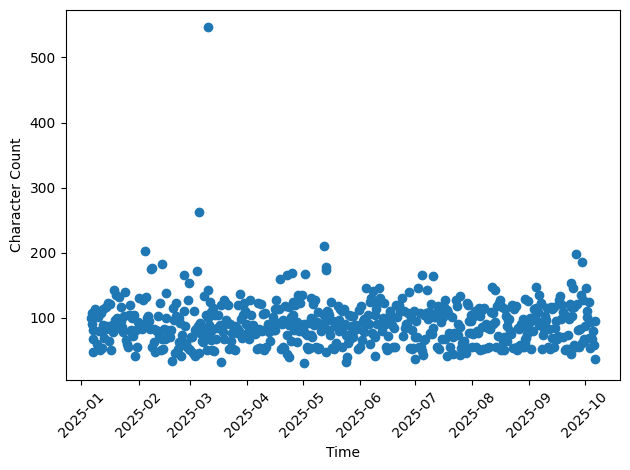

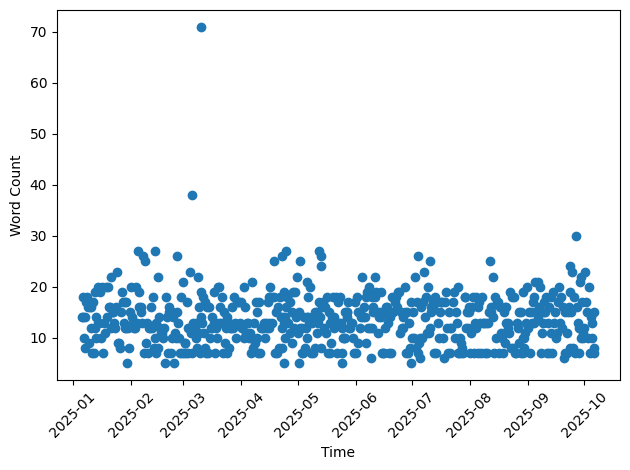

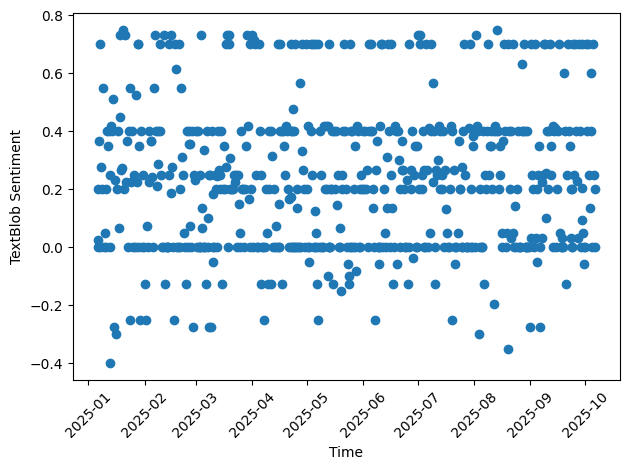

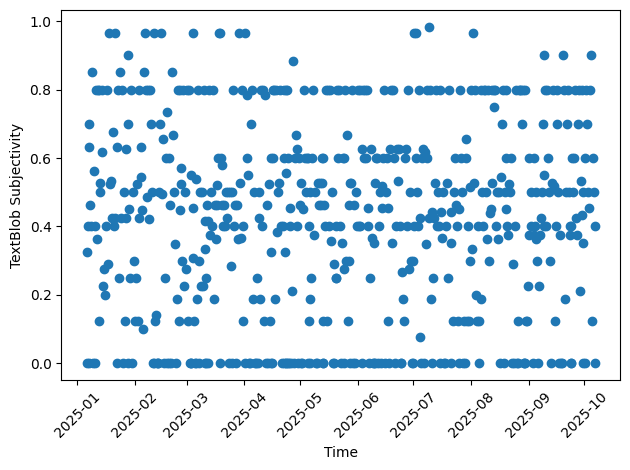

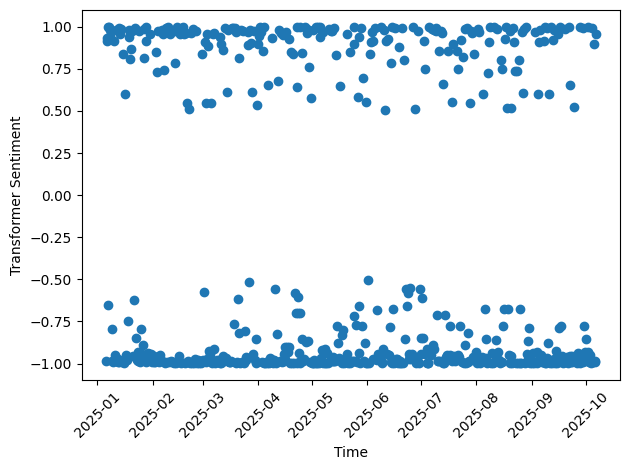

-------- P10 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

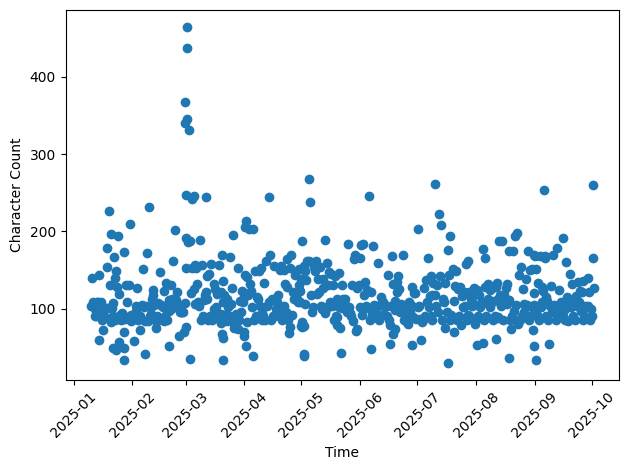

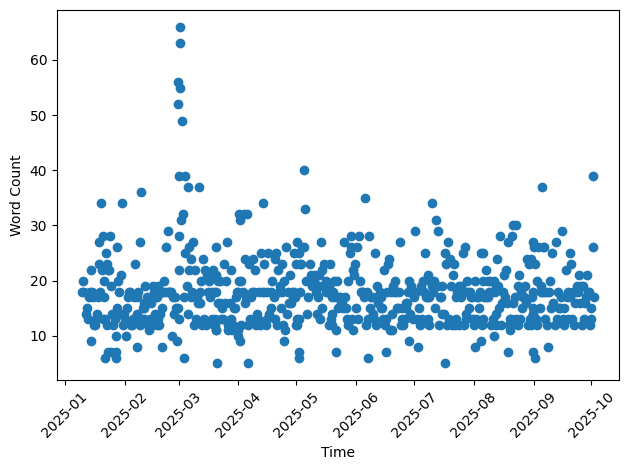

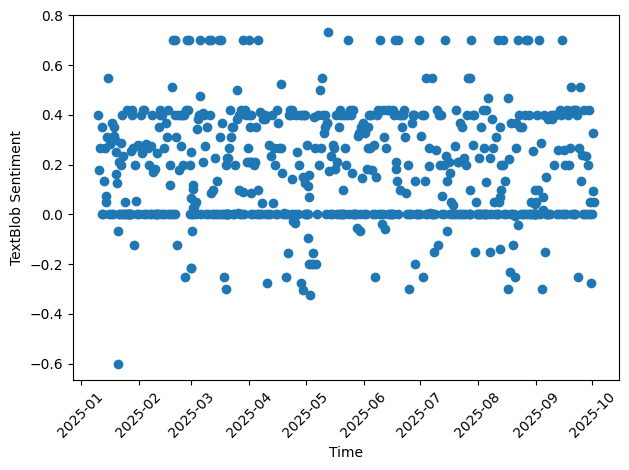

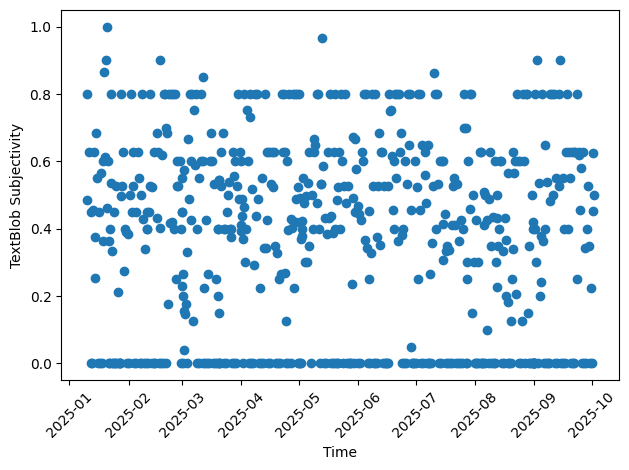

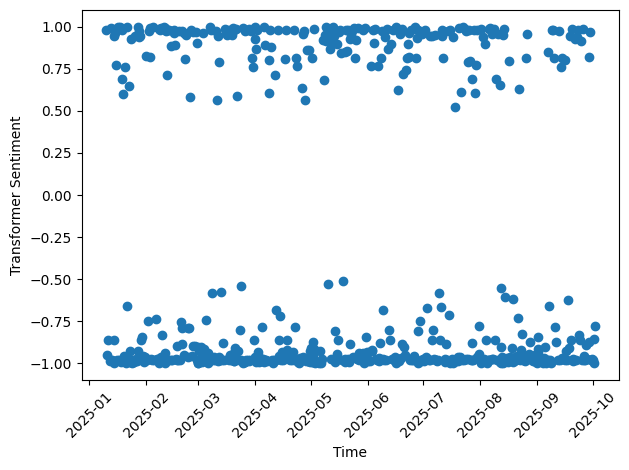

-------- P11 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

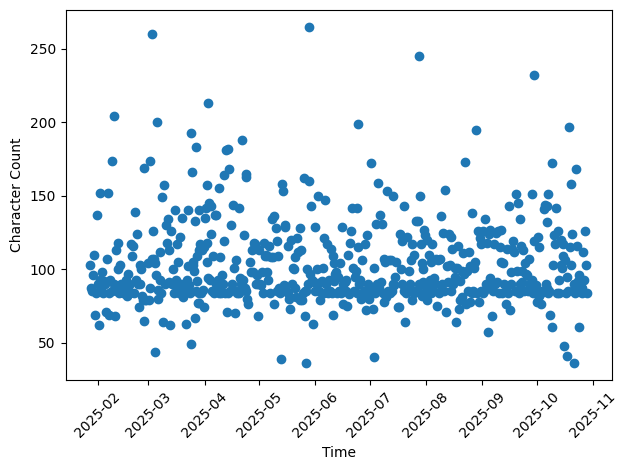

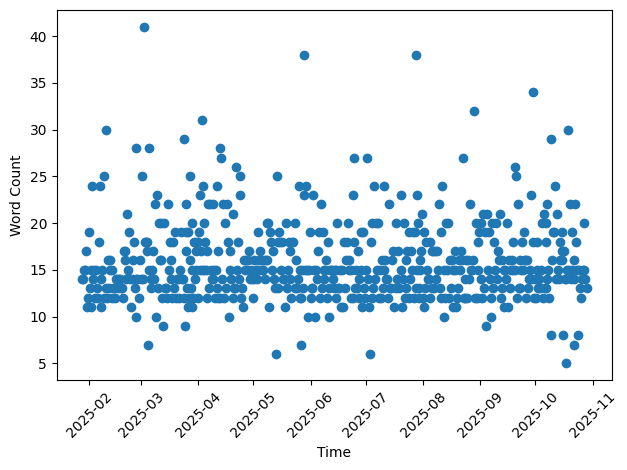

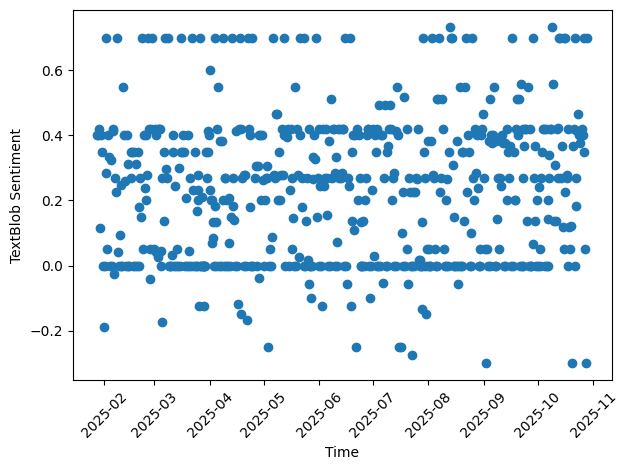

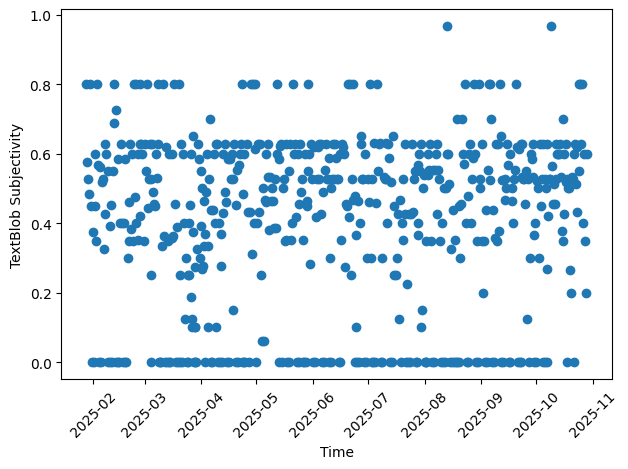

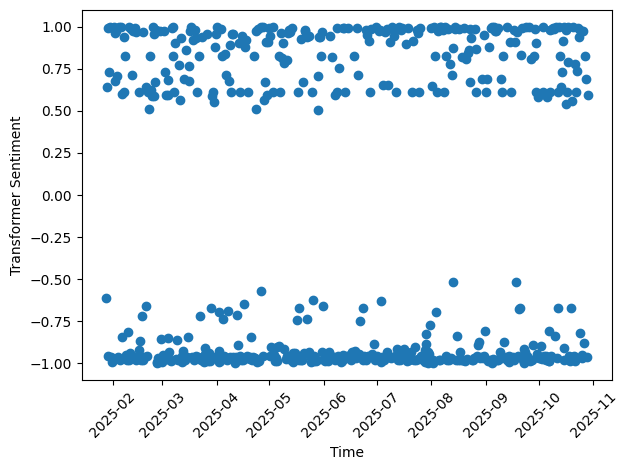

-------- P12 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

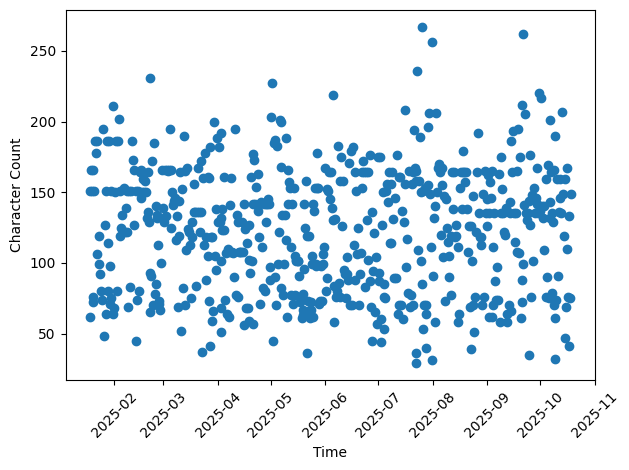

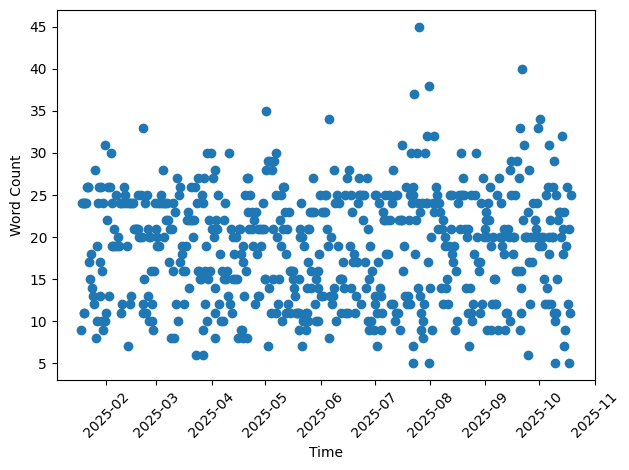

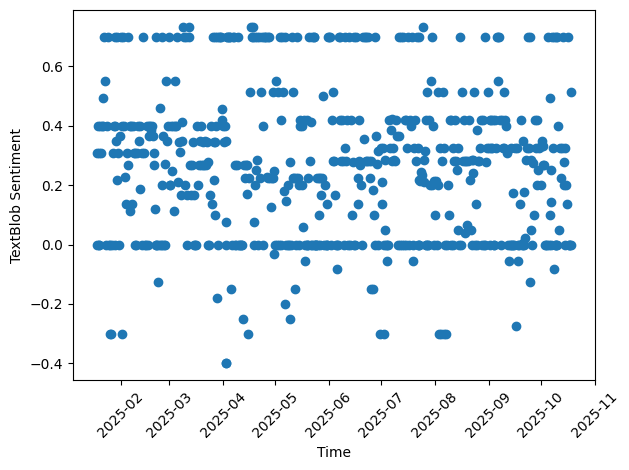

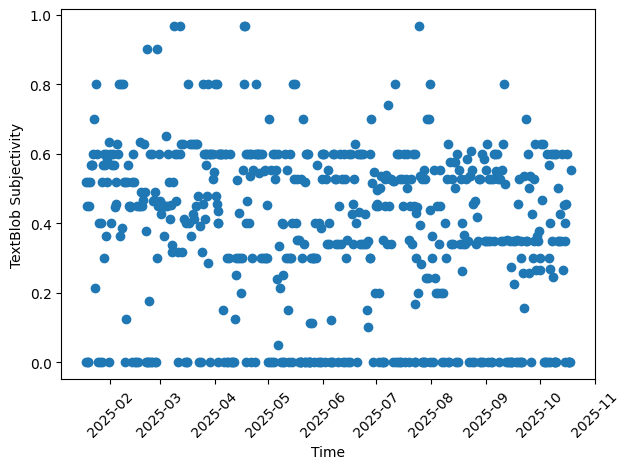

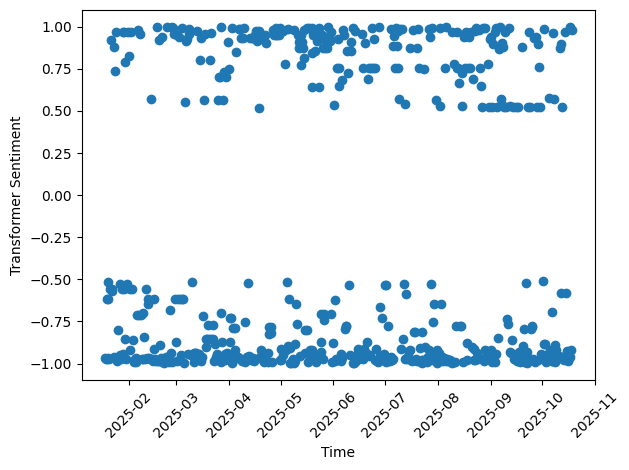

-------- P13 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

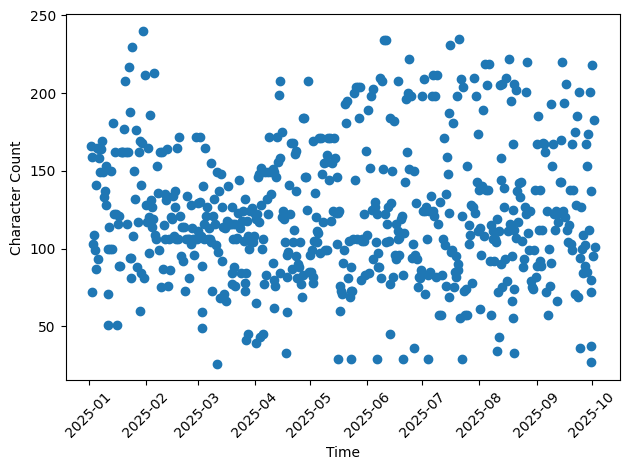

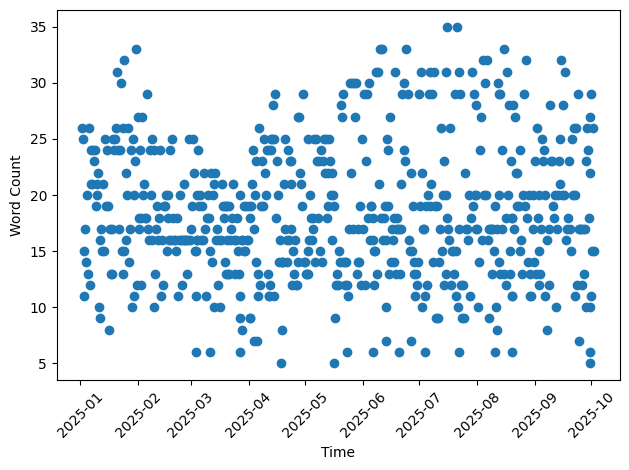

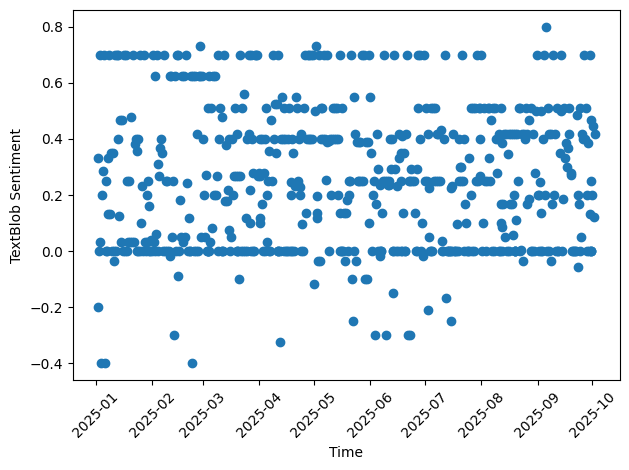

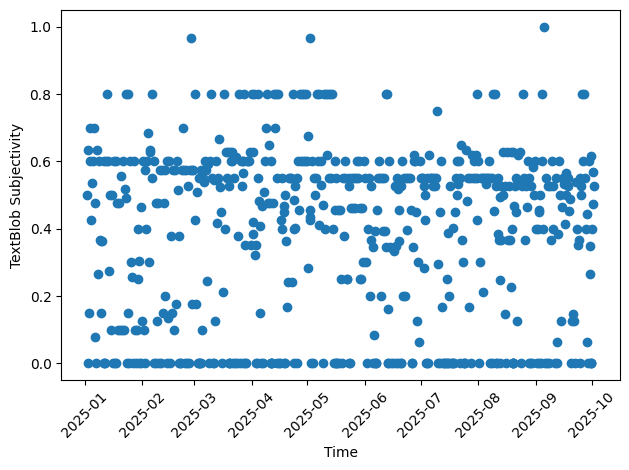

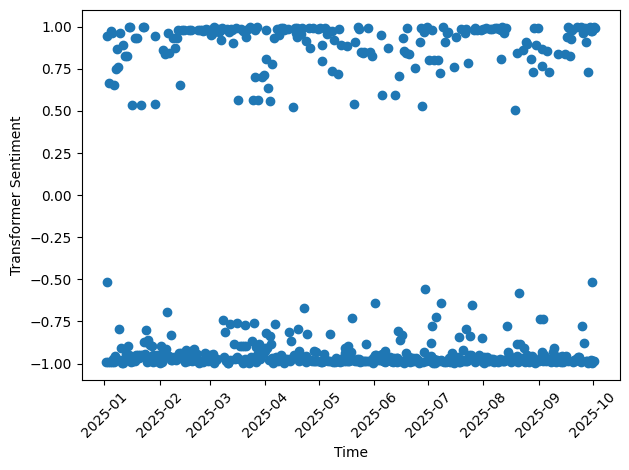

-------- P14 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

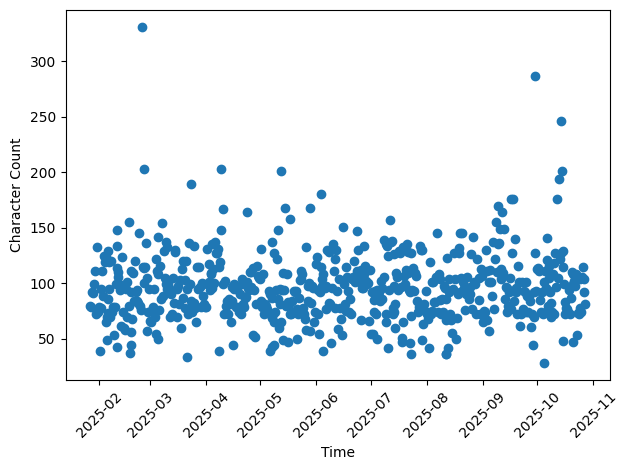

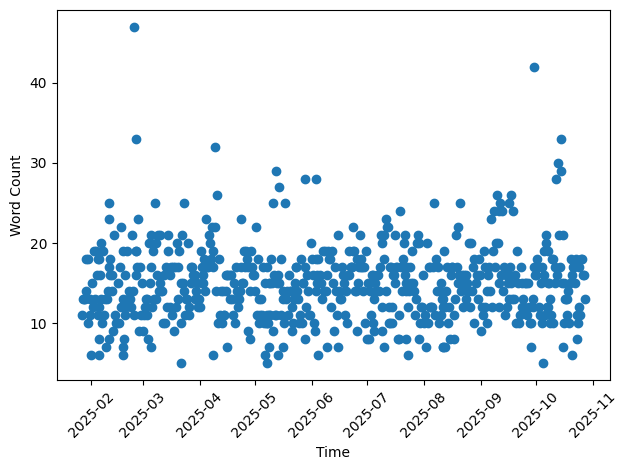

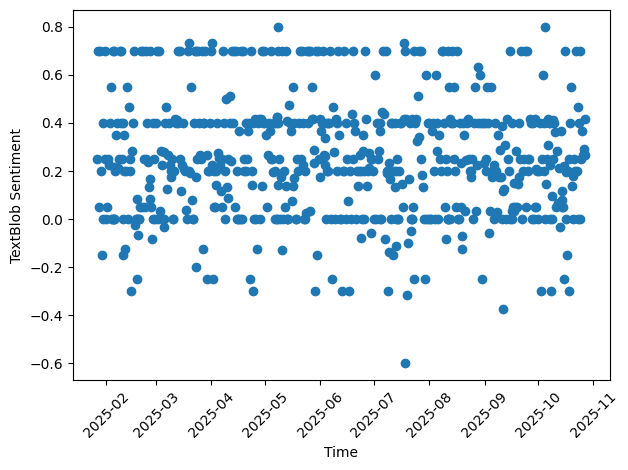

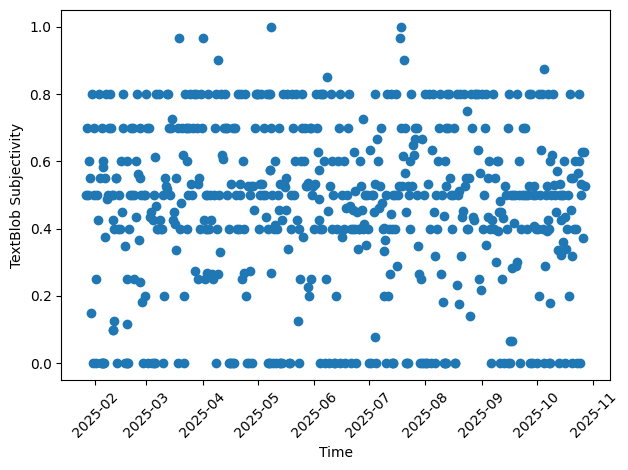

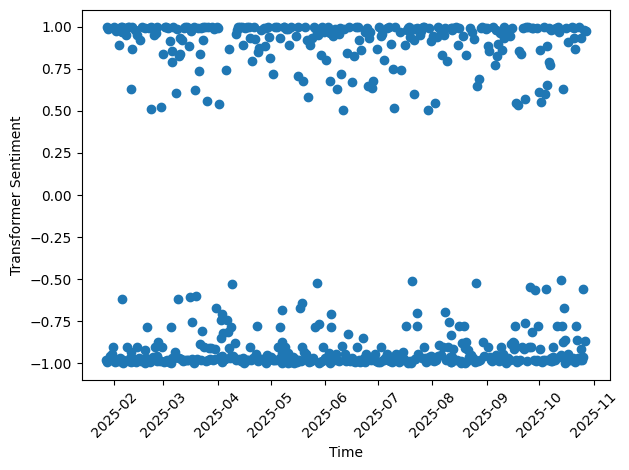

-------- P15 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

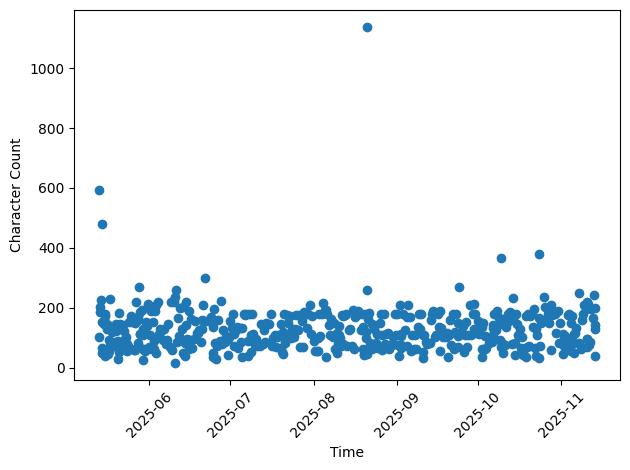

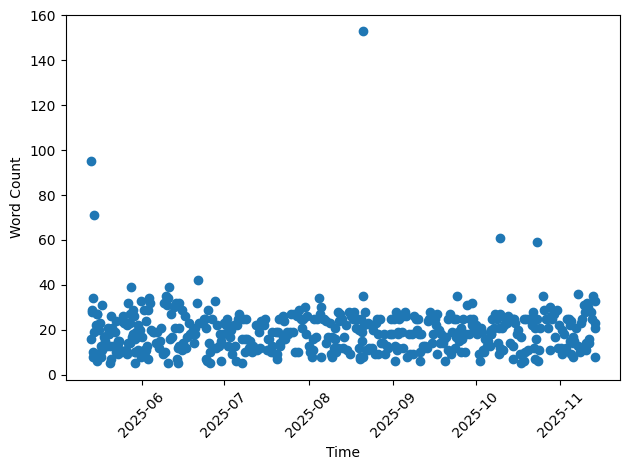

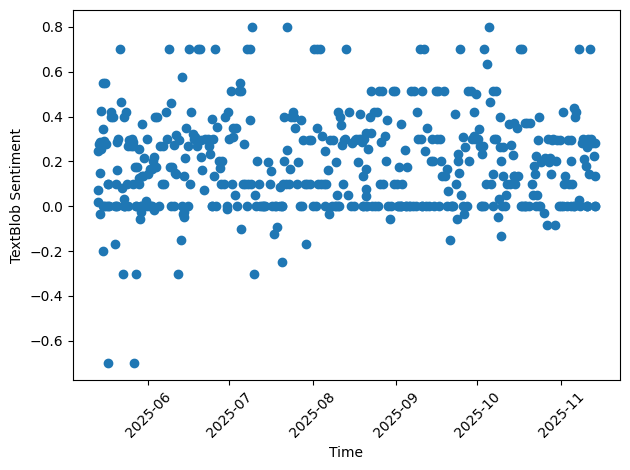

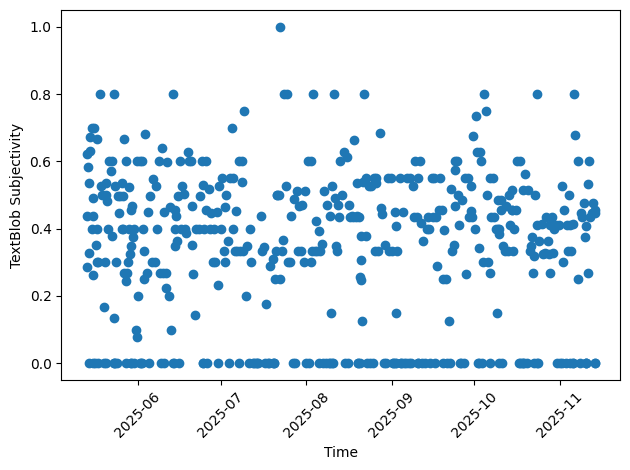

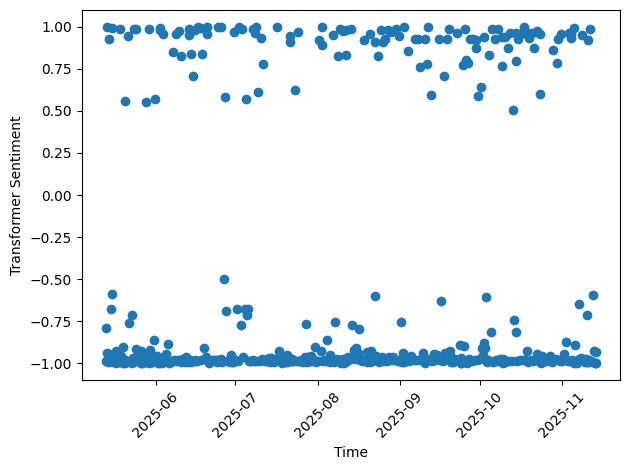

-------- P16 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

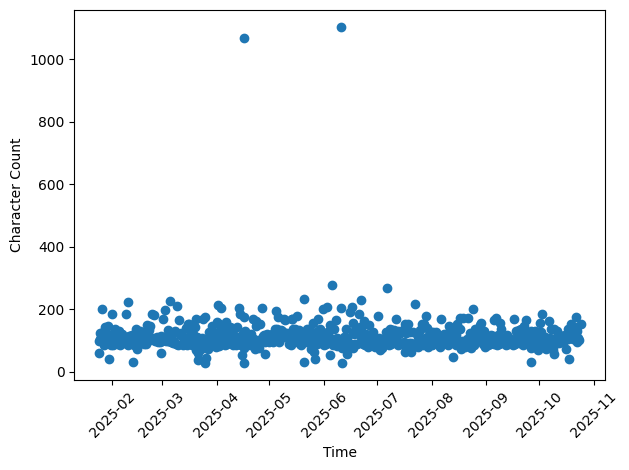

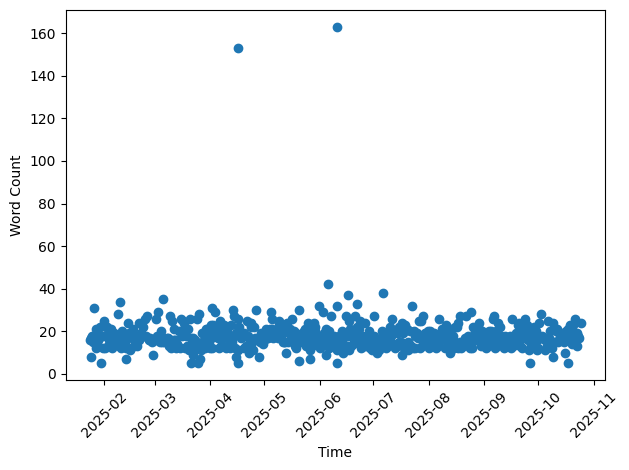

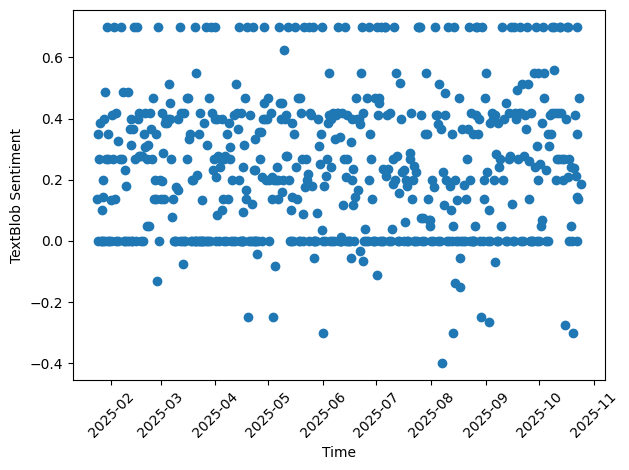

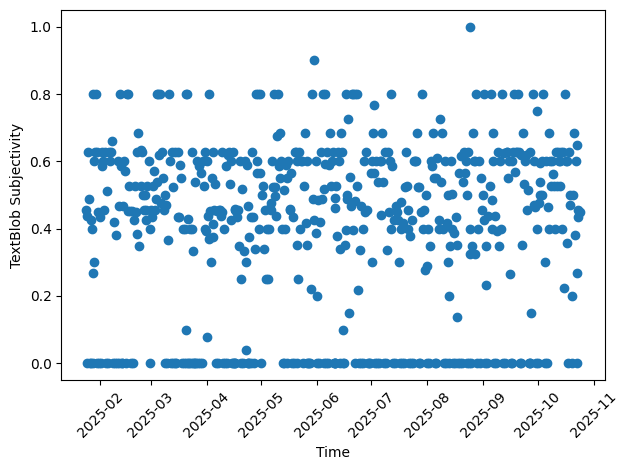

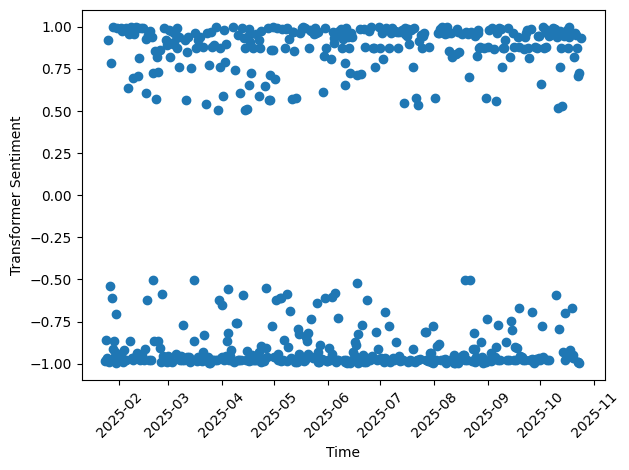

-------- P17 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

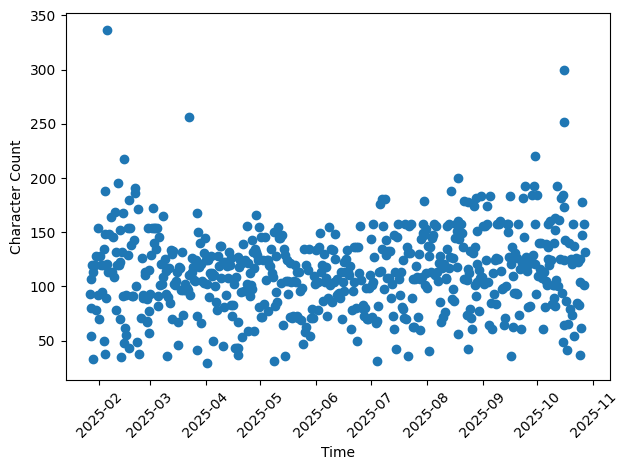

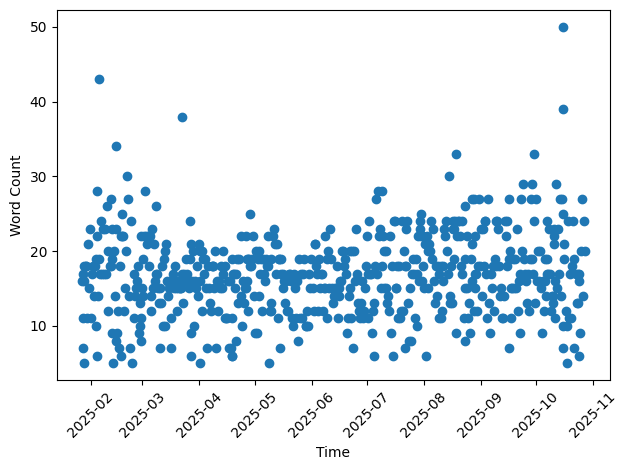

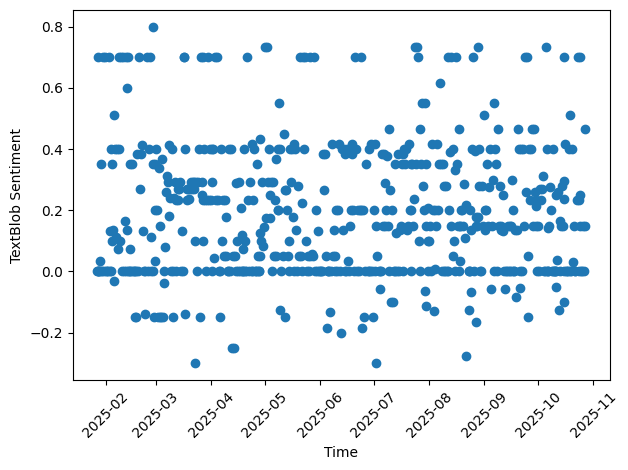

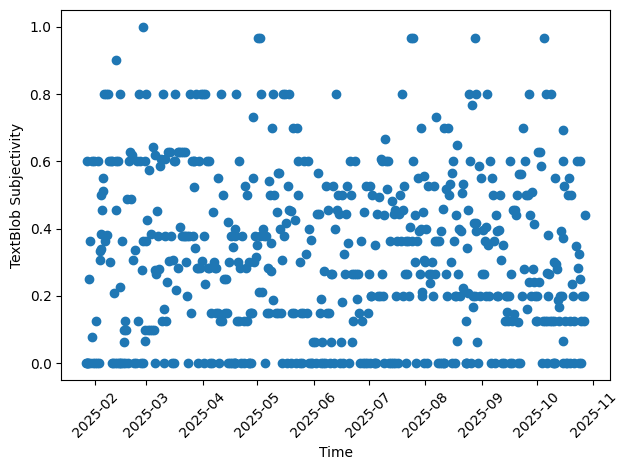

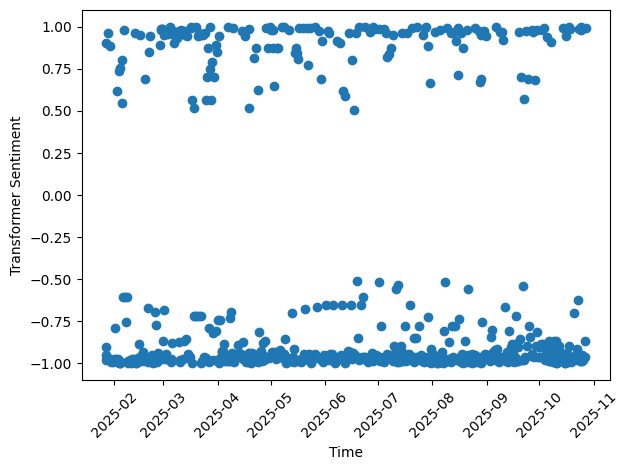

-------- P18 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

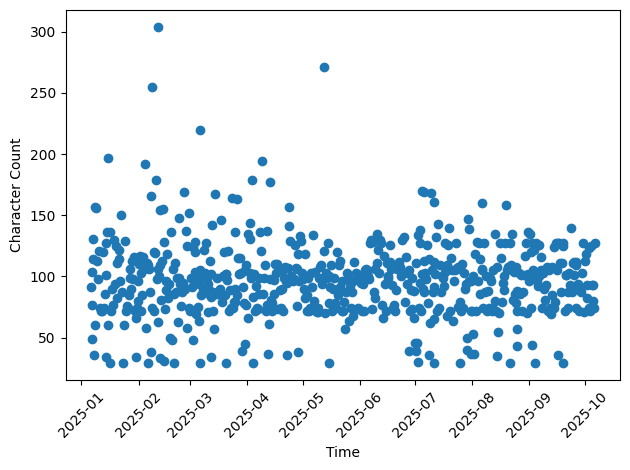

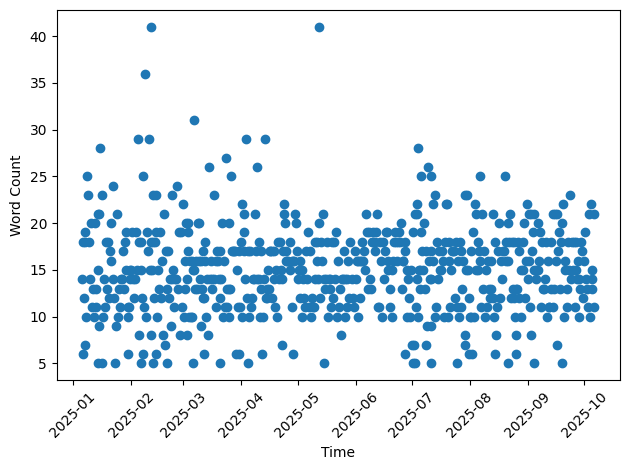

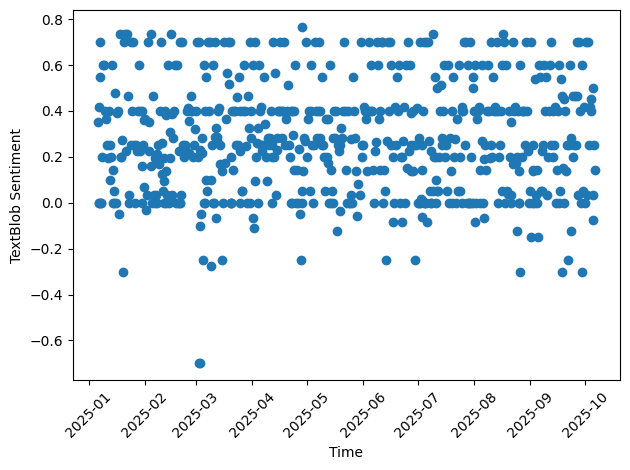

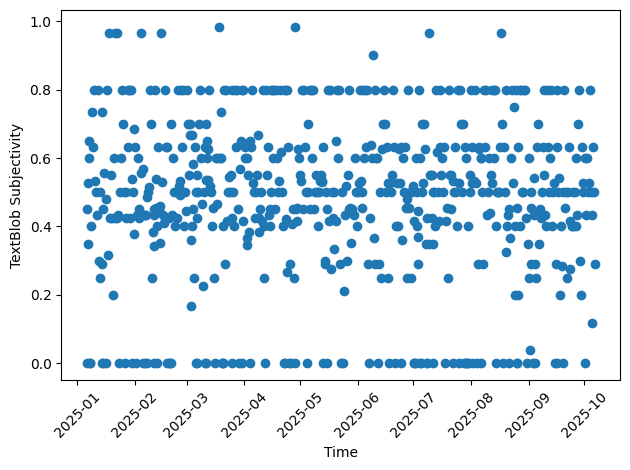

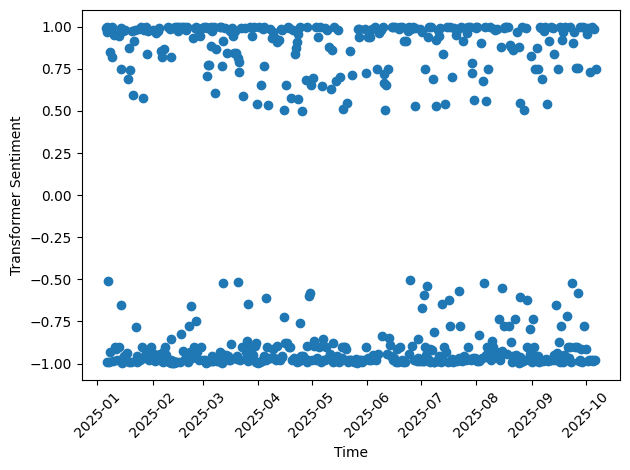

-------- P19 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

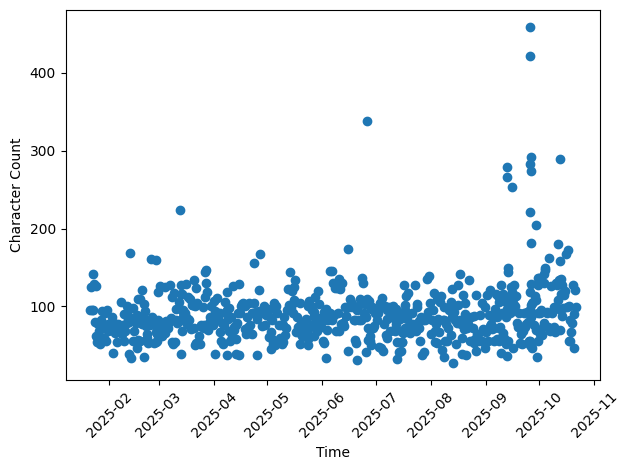

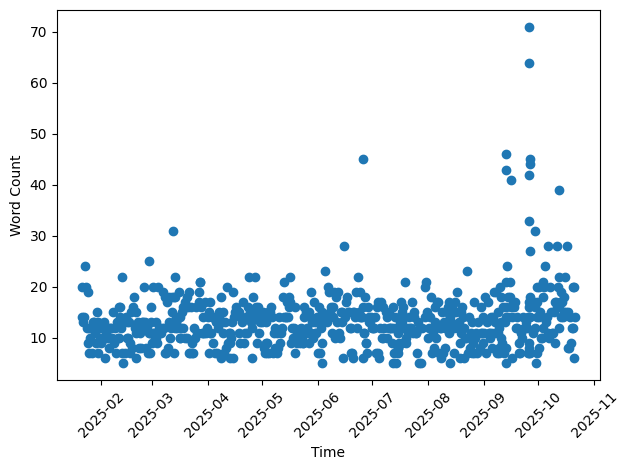

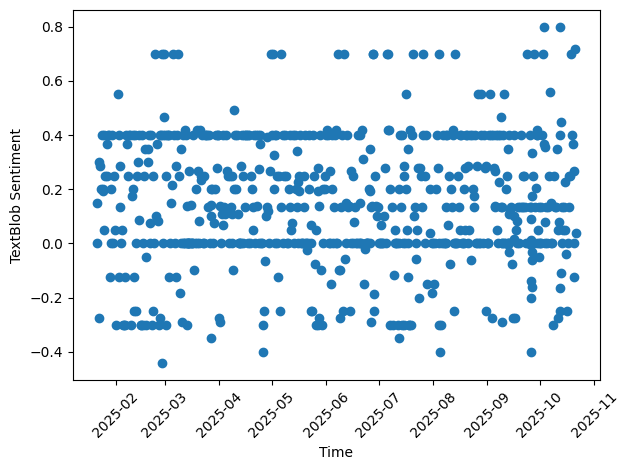

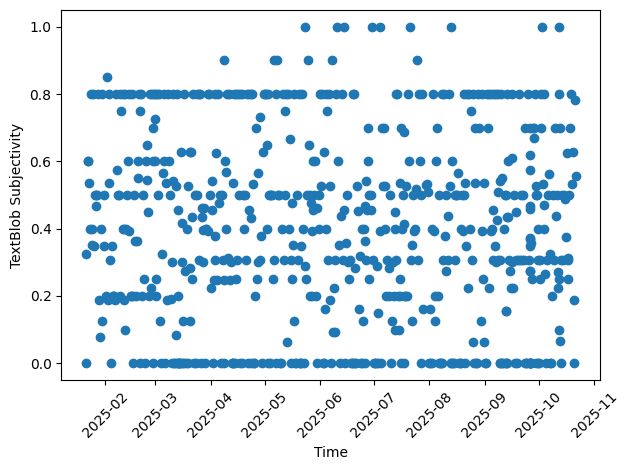

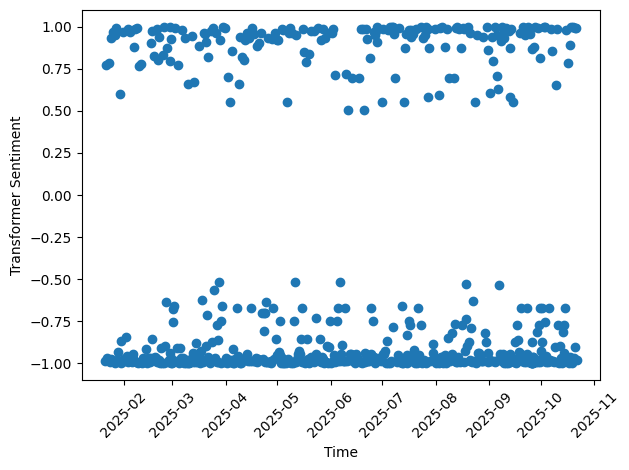

-------- P2 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

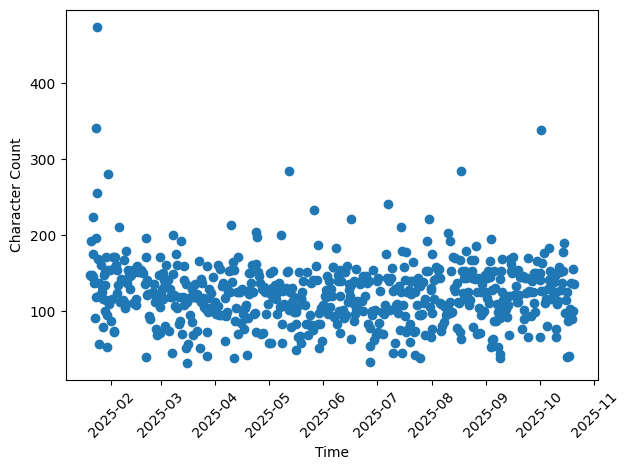

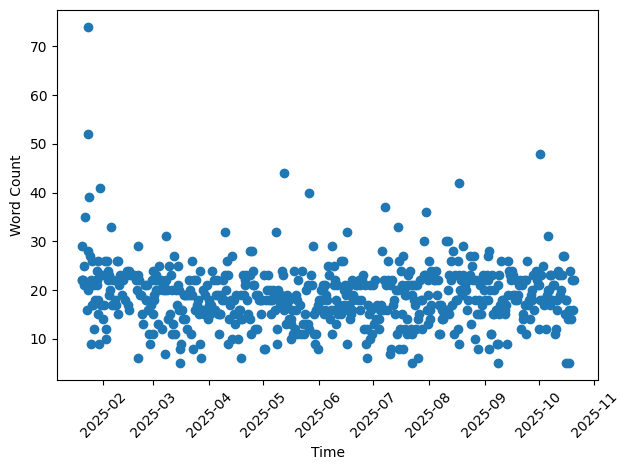

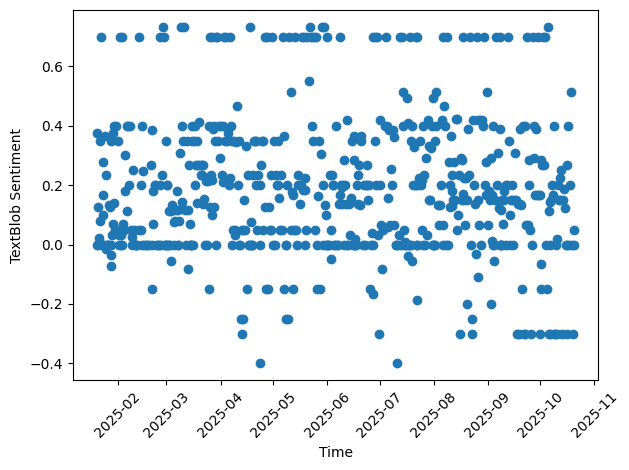

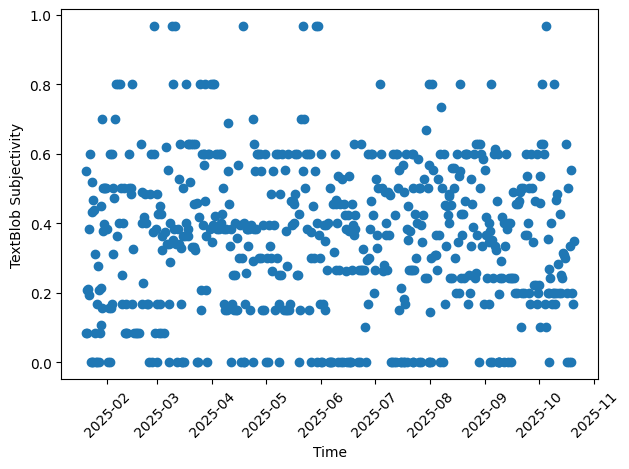

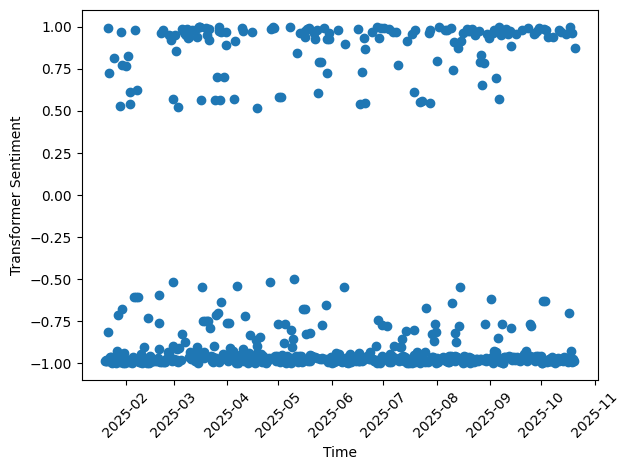

-------- P20 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

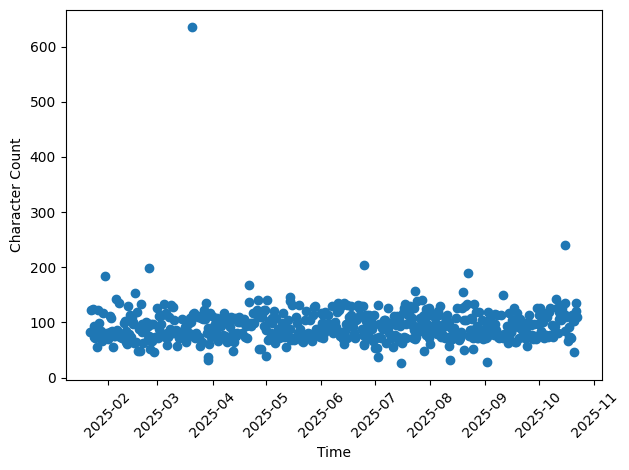

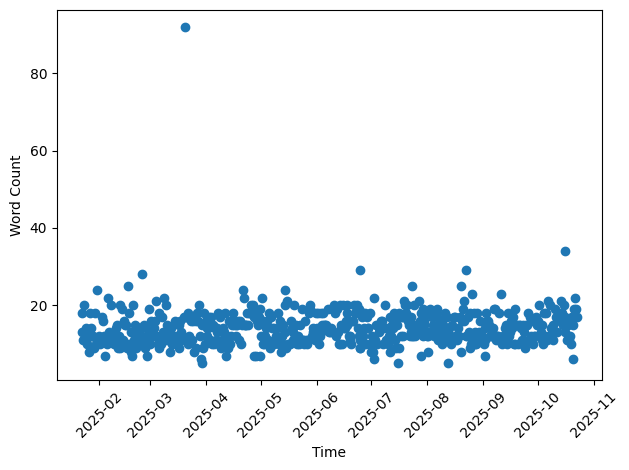

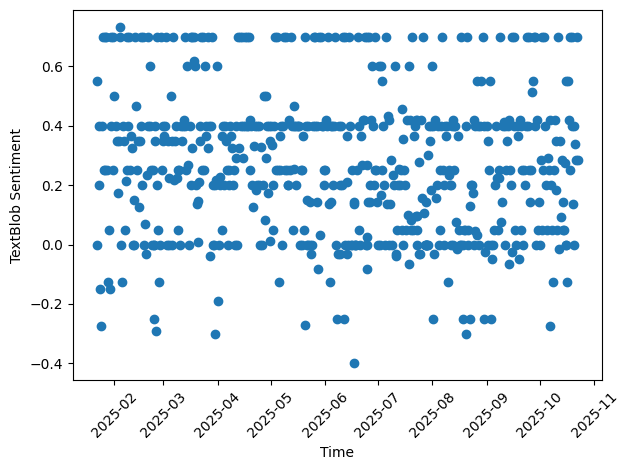

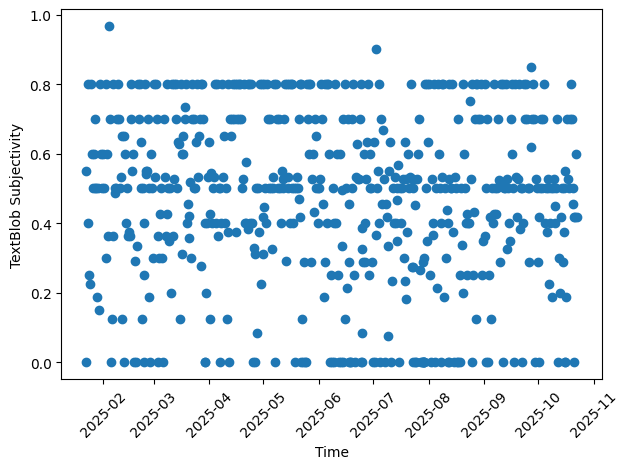

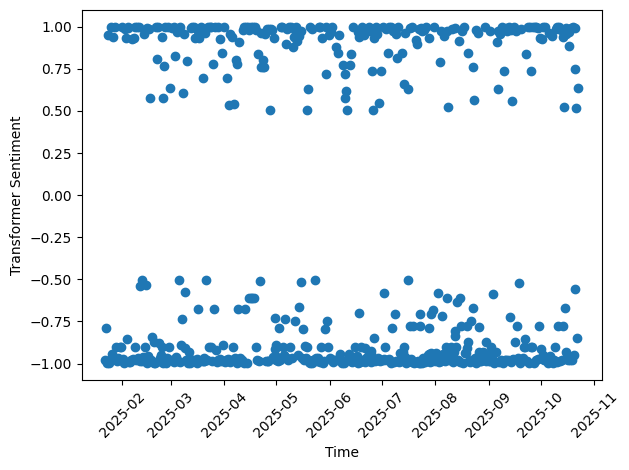

-------- P3 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

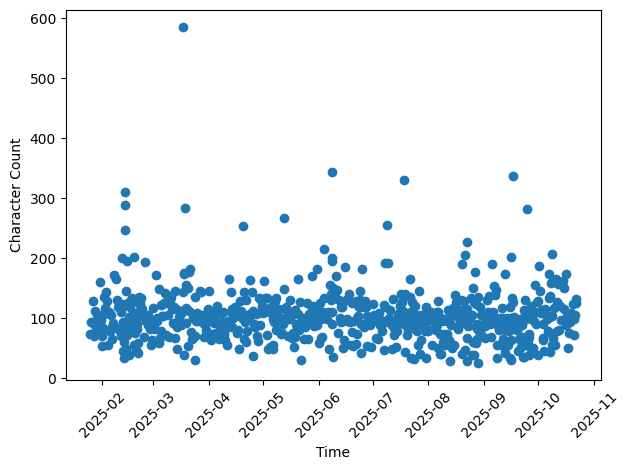

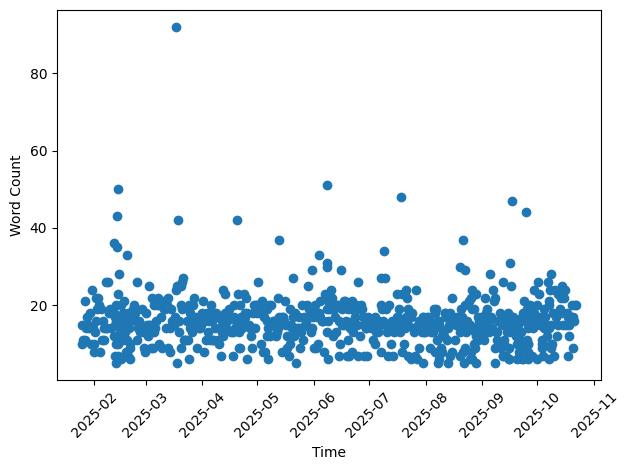

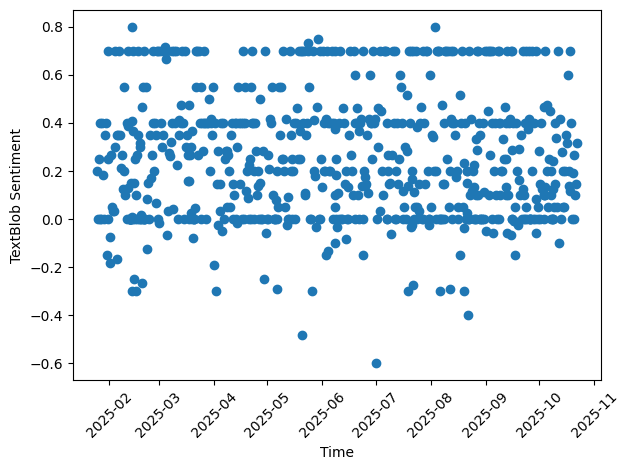

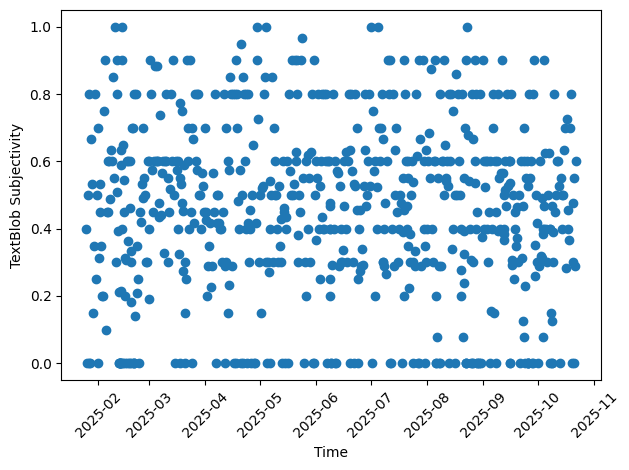

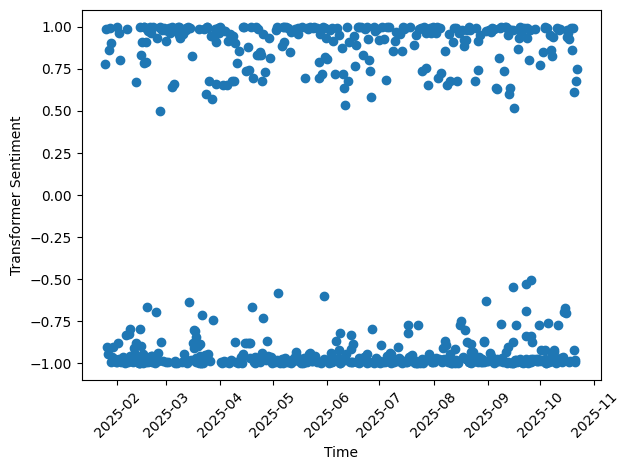

-------- P4 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

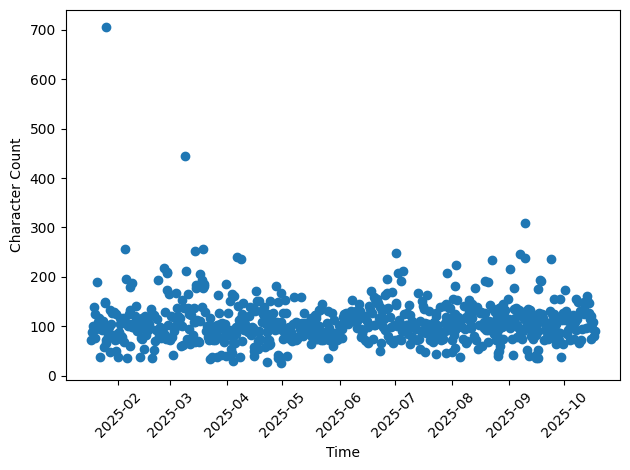

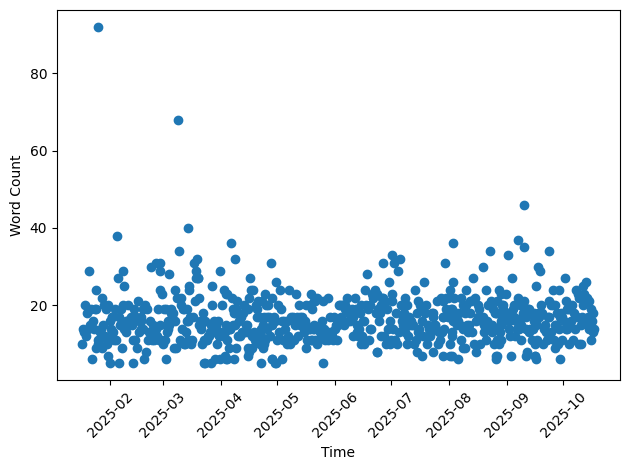

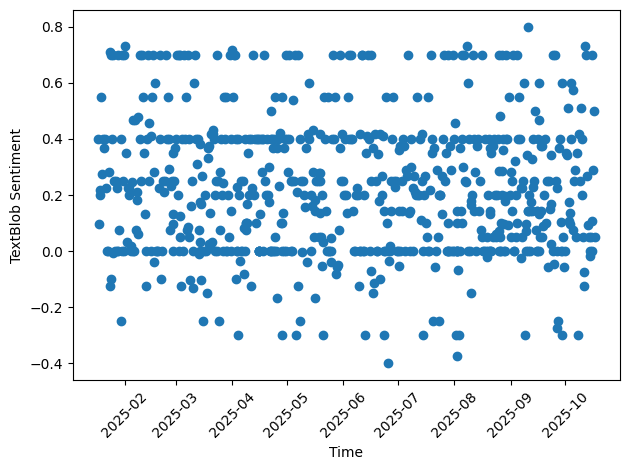

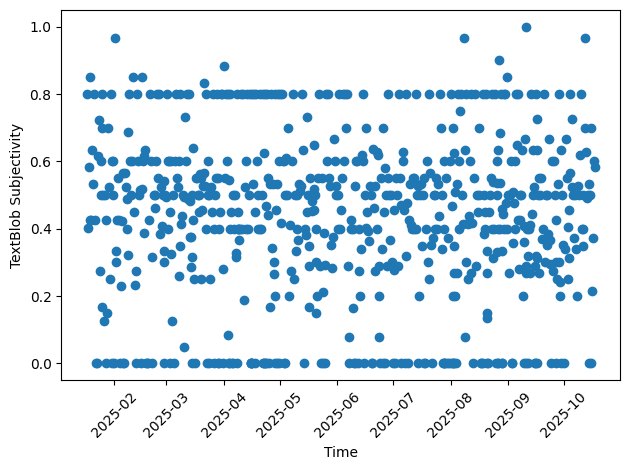

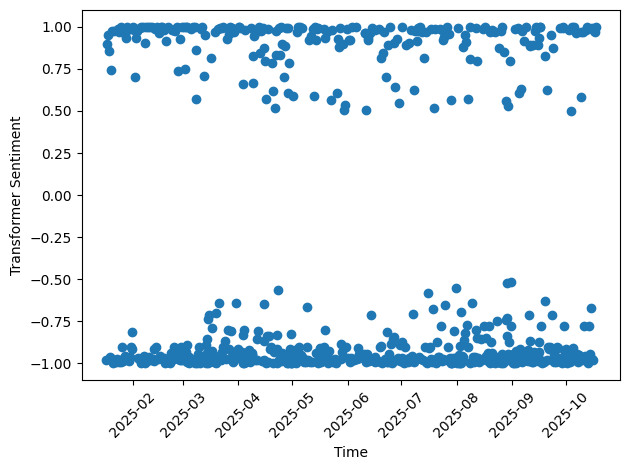

-------- P5 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

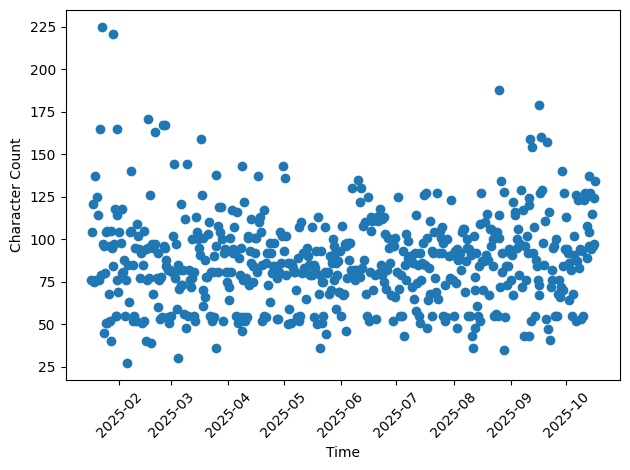

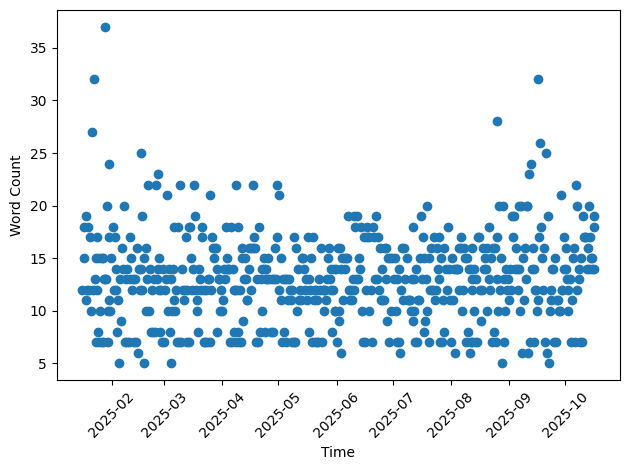

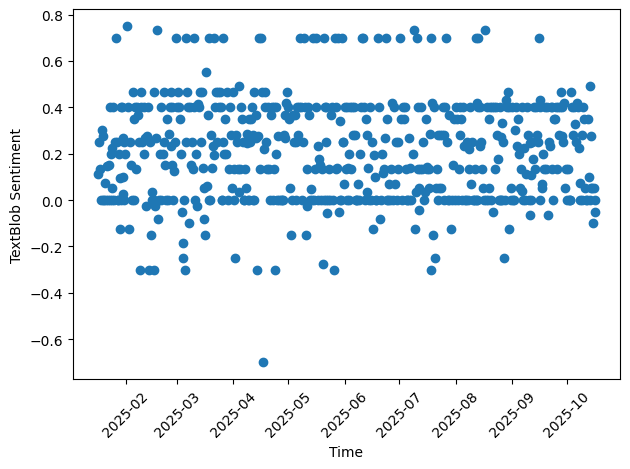

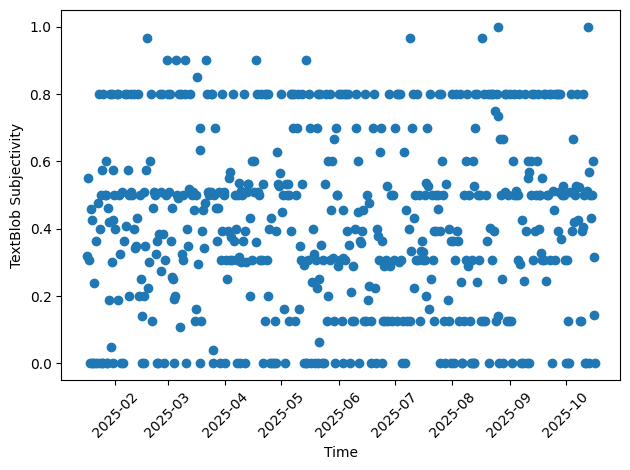

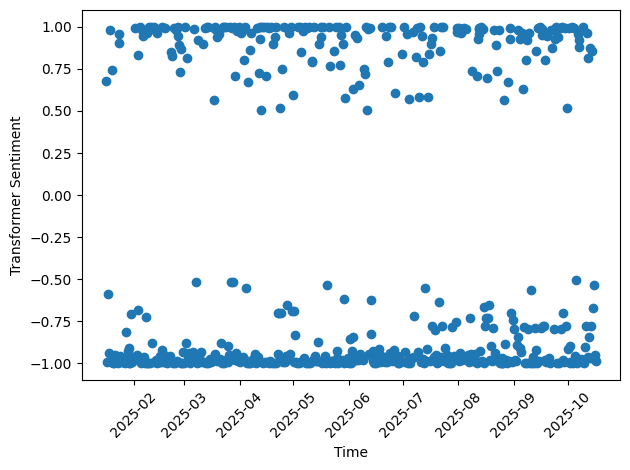

-------- P6 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

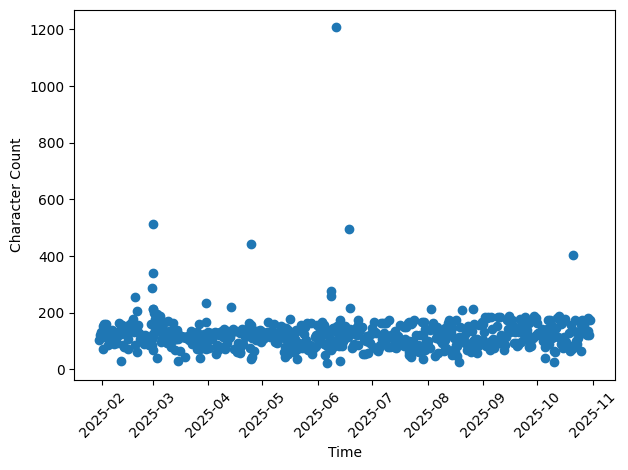

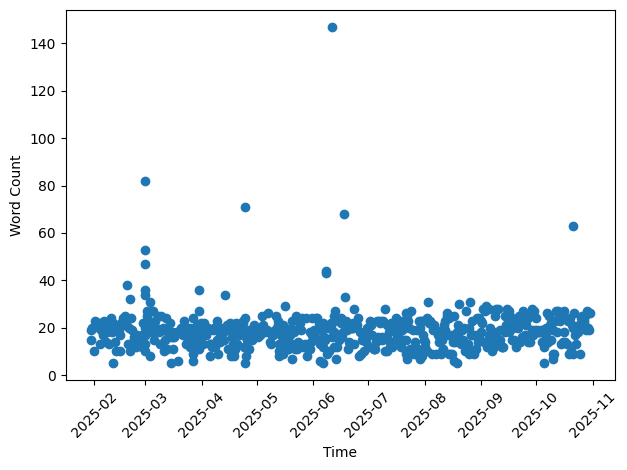

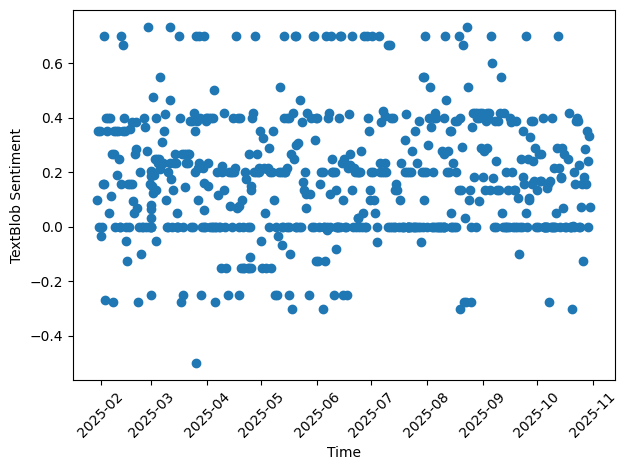

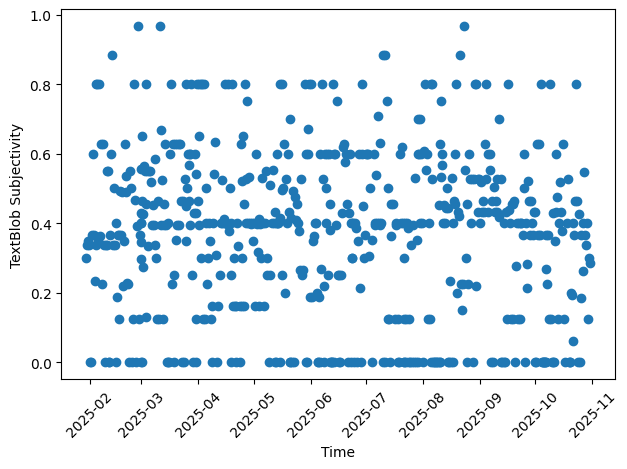

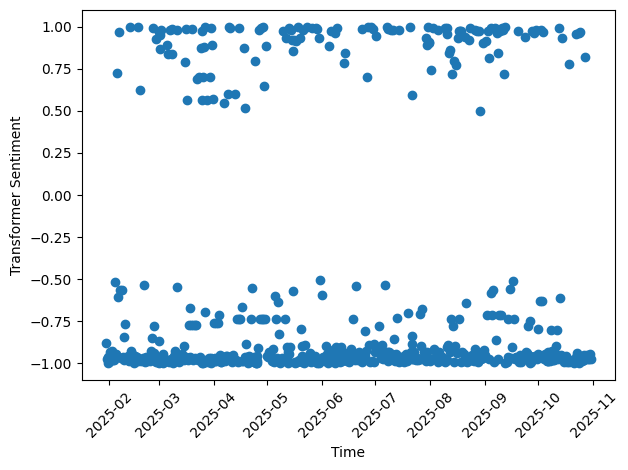

-------- P7 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

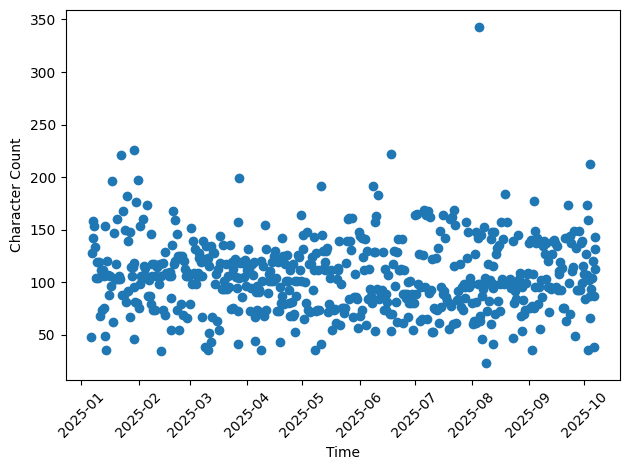

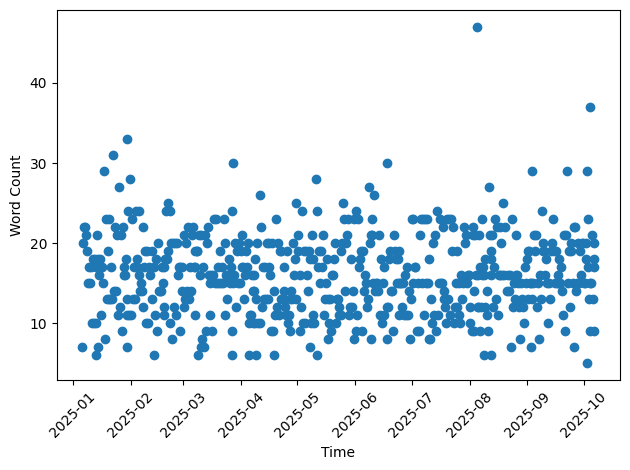

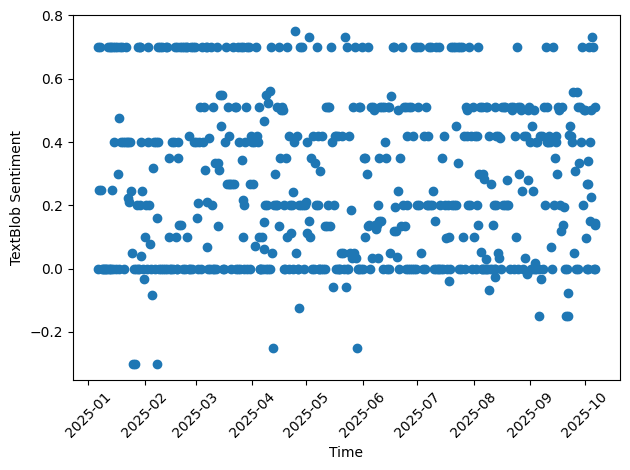

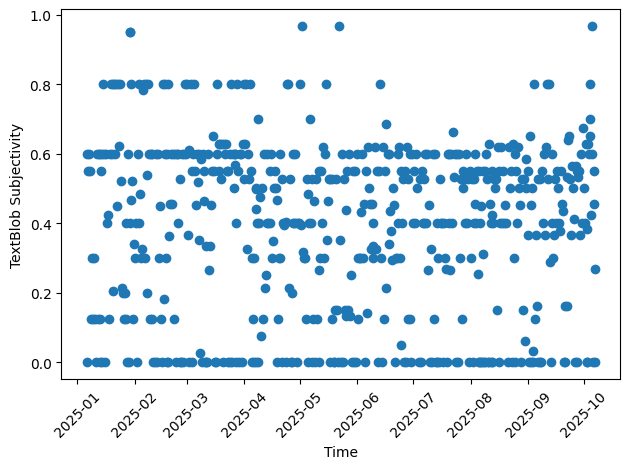

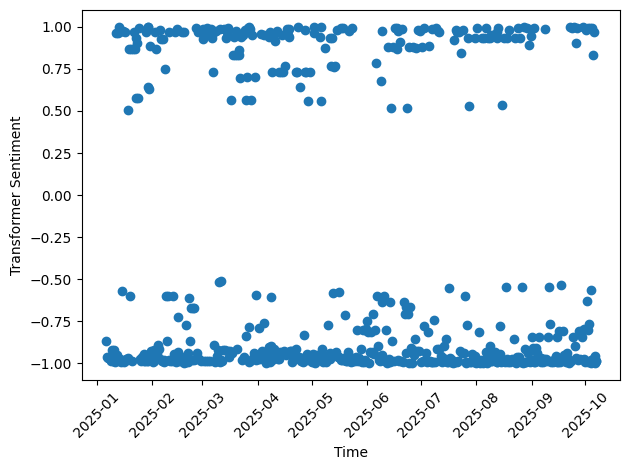

-------- P8 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

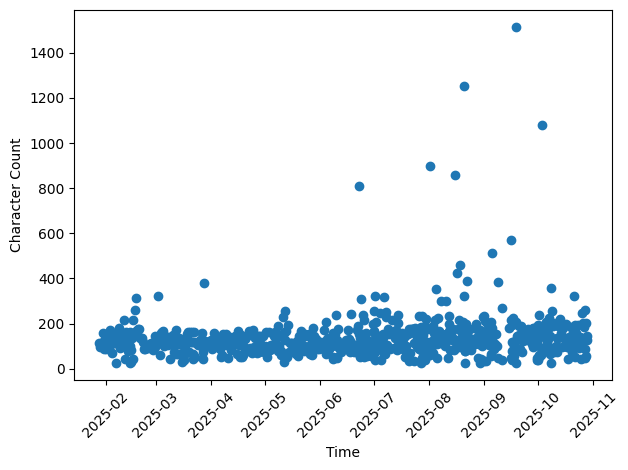

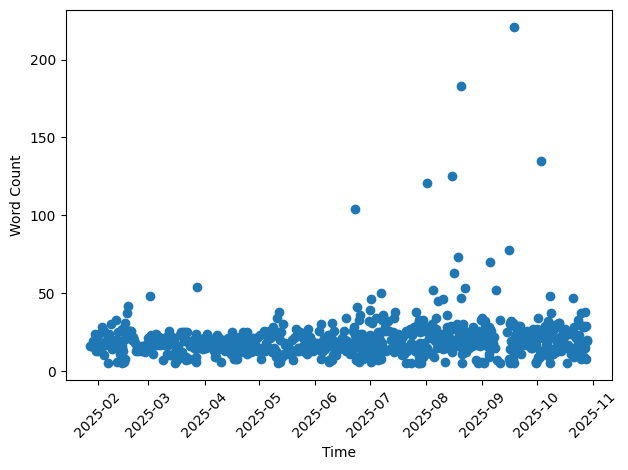

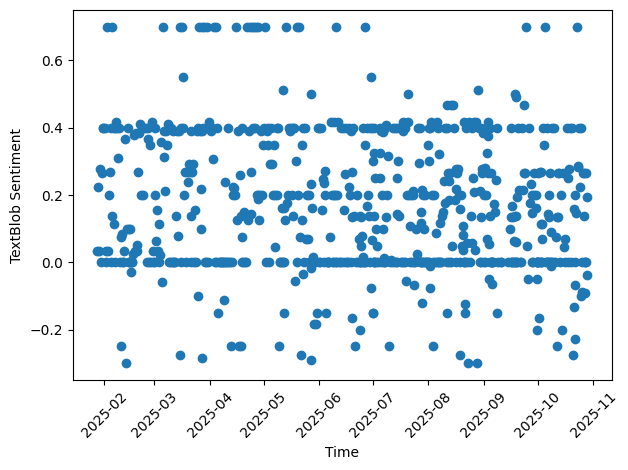

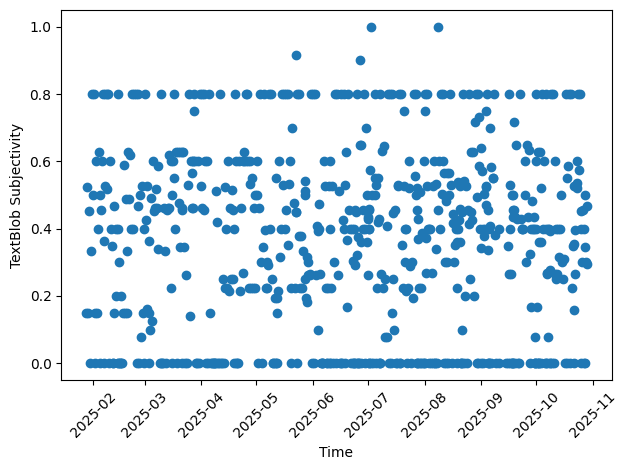

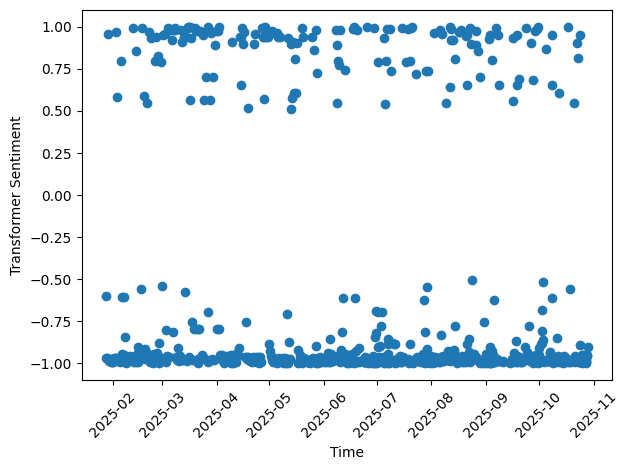

-------- P9 --------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

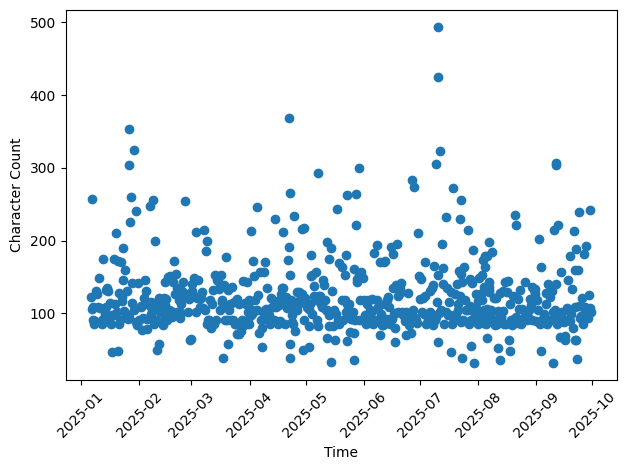

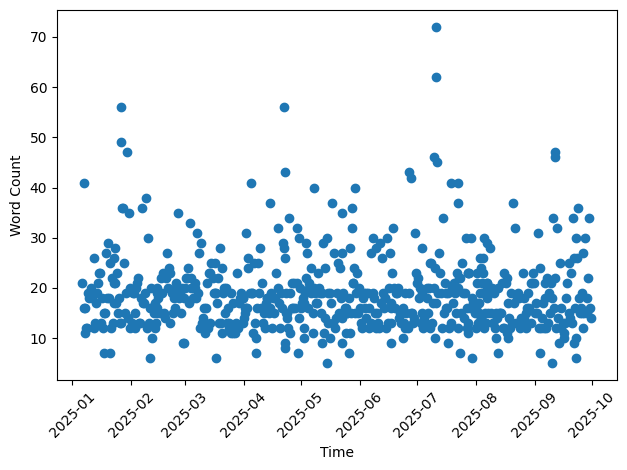

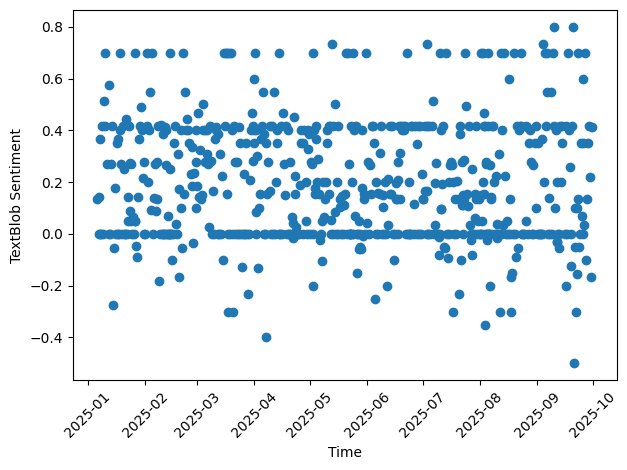

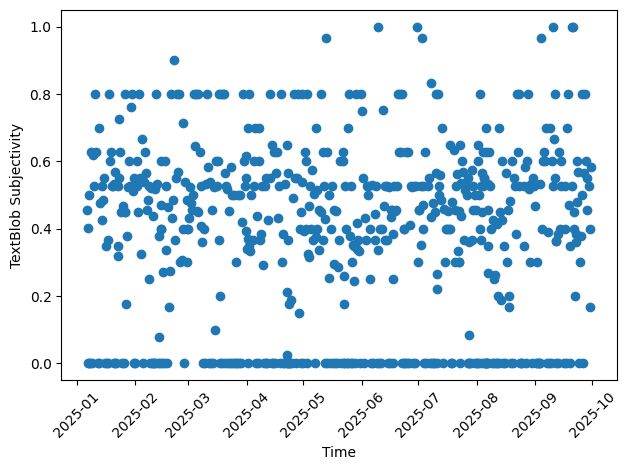

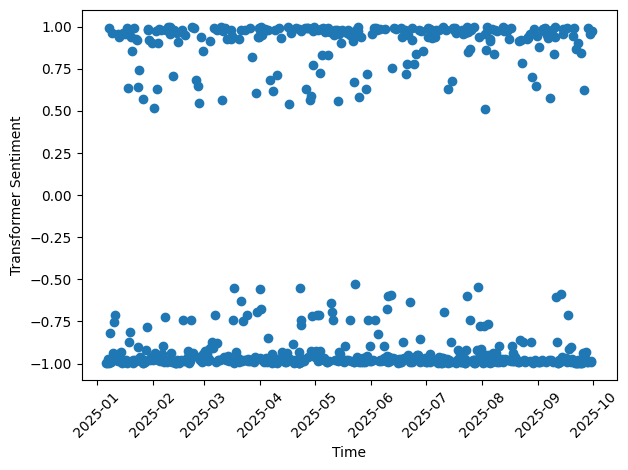

In [8]:
list_of_dfs = []
for key in nurse_notes:
    print(f"-------- {key} --------")
    temp_df = make_metric_df(key)
    plot_time_results(temp_df, metric='Character Count', file_name=f"{key.lower()}CharacterCount")
    plot_time_results(temp_df, metric='Word Count', file_name=f"{key.lower()}WordCount")
    plot_time_results(temp_df, metric='TextBlob Sentiment', file_name=f"{key.lower()}TextBlobSentiment")
    plot_time_results(temp_df, metric='TextBlob Subjectivity', file_name=f"{key.lower()}TextBlobSubjectivity")
    plot_time_results(temp_df, metric='Transformer Sentiment', file_name=f"{key.lower()}TransformerSentiment")
    list_of_dfs.append(temp_df)

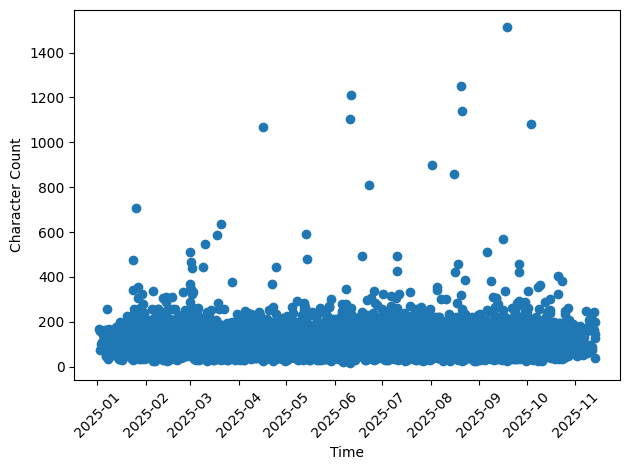

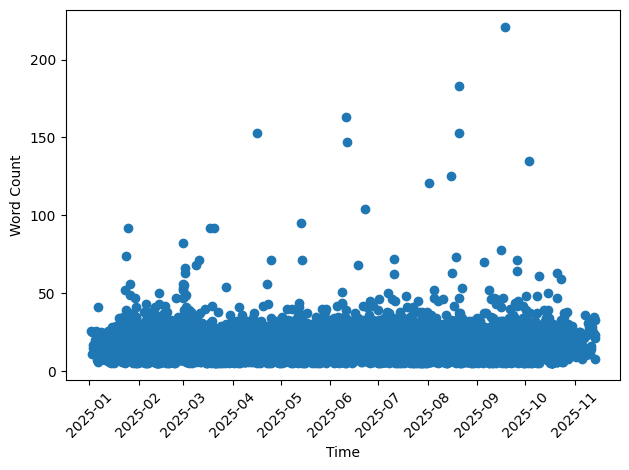

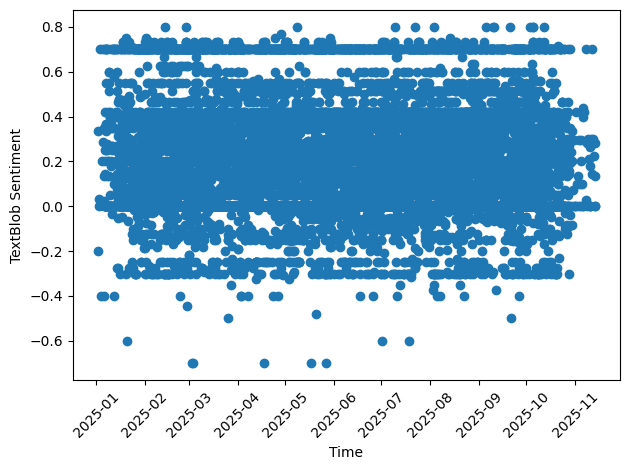

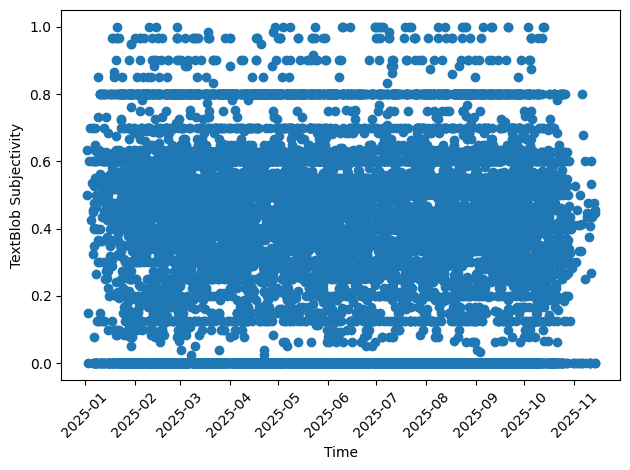

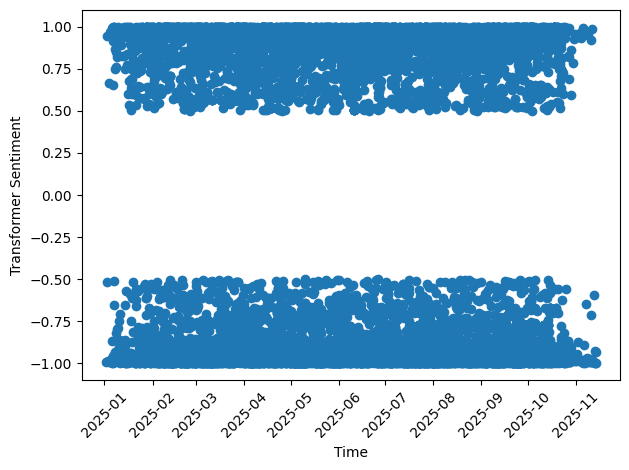

In [9]:
big_df = pd.concat(list_of_dfs)
big_df = big_df.sort_values(by=["Date", "Time"])
plot_time_results(big_df, metric='Character Count', file_name=f"allTextsCharacterCount")
plot_time_results(big_df, metric='Word Count', file_name=f"allTextsWordCount")
plot_time_results(big_df, metric='TextBlob Sentiment', file_name=f"allTextsTextBlobSentiment")
plot_time_results(big_df, metric='TextBlob Subjectivity', file_name=f"allTextsTextBlobSubjectivity")
plot_time_results(big_df, metric='Transformer Sentiment', file_name=f"allTextsTransformerSentiment")